<!-- # Demo: Mapping SIMP 0136 with NIRSpec

In this tutorial, we will demonstrate how to use `spectralmap` to analyze time-series observations. We will use a sequence of NIRSpec observations of the brown dwarf SIMP 0136 to recover a spectroscopic map of its surface.

**We will cover:**
1. Loading and preprocessing the lightcurve data.
2. Inverting the lightcurves to obtain surface maps.
3. Clustering the map pixels to identify distinct spectral regions.
4. Extracting and analyzing the spectra of these regions.

Let's get started! -->

In [39]:
import matplotlib.pyplot as plt
from spectralmap.plotting import COLOR_LIST, PAPER_FIGURES_DIR

import spectralmap
print(f"spectralmap version: {spectralmap.__version__}")


spectralmap version: 0.1.0


In [40]:
import numpy as np
print(np.__version__)
np.bool = bool
import starry
starry.config.lazy = False  # disable lazy evaluation
starry.config.quiet = True  # disable warnings
map = starry.Map(ydeg=4)

1.21.6


In [41]:
A=map.design_matrix(theta=np.linspace(0, 360, 100))

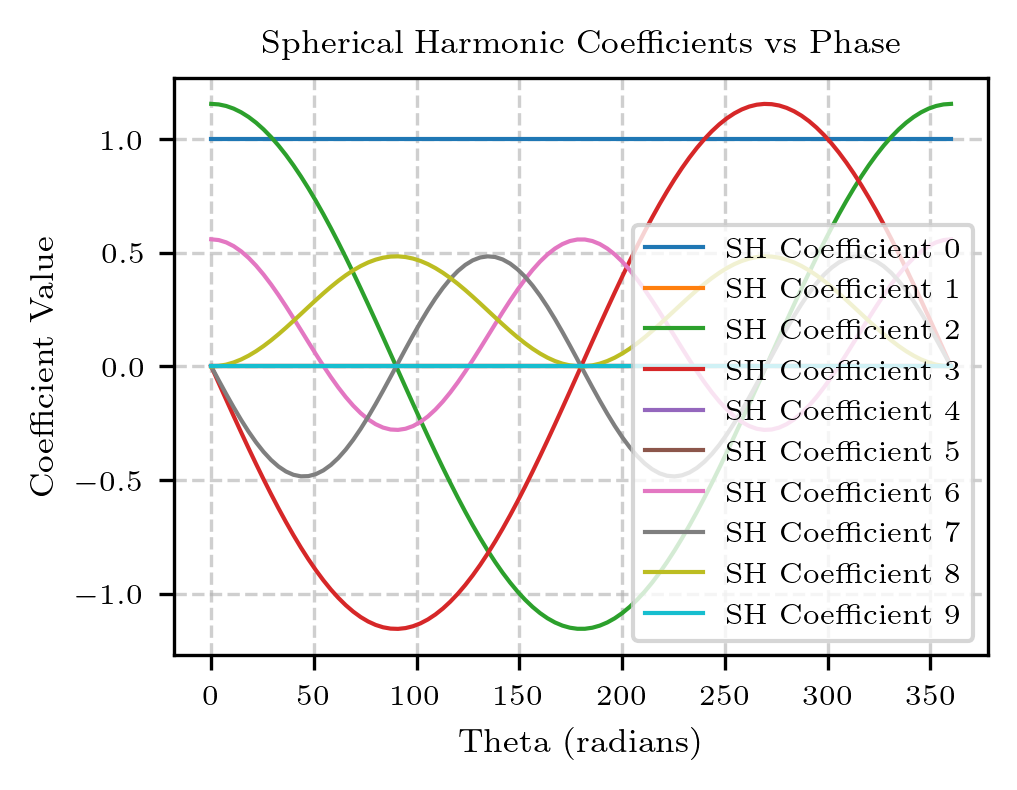

In [42]:
theta_grid = np.linspace(0, 360, 100)
import matplotlib.pyplot as plt
for i in range(10):
    plt.plot(theta_grid, A[:, i], label=f'SH Coefficient {i}')
plt.legend()
plt.xlabel('Theta (radians)')
plt.ylabel('Coefficient Value')
plt.title('Spherical Harmonic Coefficients vs Phase')
plt.show()

In [43]:
import matplotlib.pyplot as plt

import spectralmap
print(f"spectralmap version: {spectralmap.__version__}")

spectralmap version: 0.1.0


## 1. Load Data
Before we apply spectralmap to a spectroscopic time series, we will need to read them in, sort them by phase, and normalize the flux.

In [ ]:
import numpy as np

# 1. Load the data files
theta = np.load("data/SIMP0136_NIRSpec.npz")["theta"]
wl = np.load("data/SIMP0136_NIRSpec.npz")["wl"]
flux_raw = np.load("data/SIMP0136_NIRSpec.npz")["flux_raw"]
flux_err_raw = np.load("data/SIMP0136_NIRSpec.npz")["flux_err_raw"]

flux_raw = flux_raw[wl>0.9]
flux_err_raw = flux_err_raw[wl>0.9]
wl = wl[wl>0.9]

# 2. Normalize the lightcurves
# We normalize by the mean amplitude over time for each wavelength
amplitudes = np.nanmean(flux_raw, axis=1)
flux = (flux_raw.T / amplitudes).T
flux_err = (flux_err_raw.T / amplitudes).T

print(f"Loaded data with shape: {flux.shape} (wavelengths, time points)")
print(f"Wavelength range: {wl.min():.2f}, {wl.max():.2f} microns")
print(f"Phase range: {theta.min():.2f}, {theta.max():.2f} radians")

Loaded data with shape: (359, 24) (wavelengths, time points)
Wavelength range: 0.92, 5.27 microns
Phase range: 0.00, 345.00 radians


## 2. Inversion with SpectralMap

First, we organize the data into a `LightCurveData` object. We must specify the inclination of the object (here assumed to be 80 degrees).

In [45]:
from spectralmap.mapping import LightCurveData
data = LightCurveData(theta=theta, flux=flux[:, :], flux_err=flux_err[:, :], inc=80)

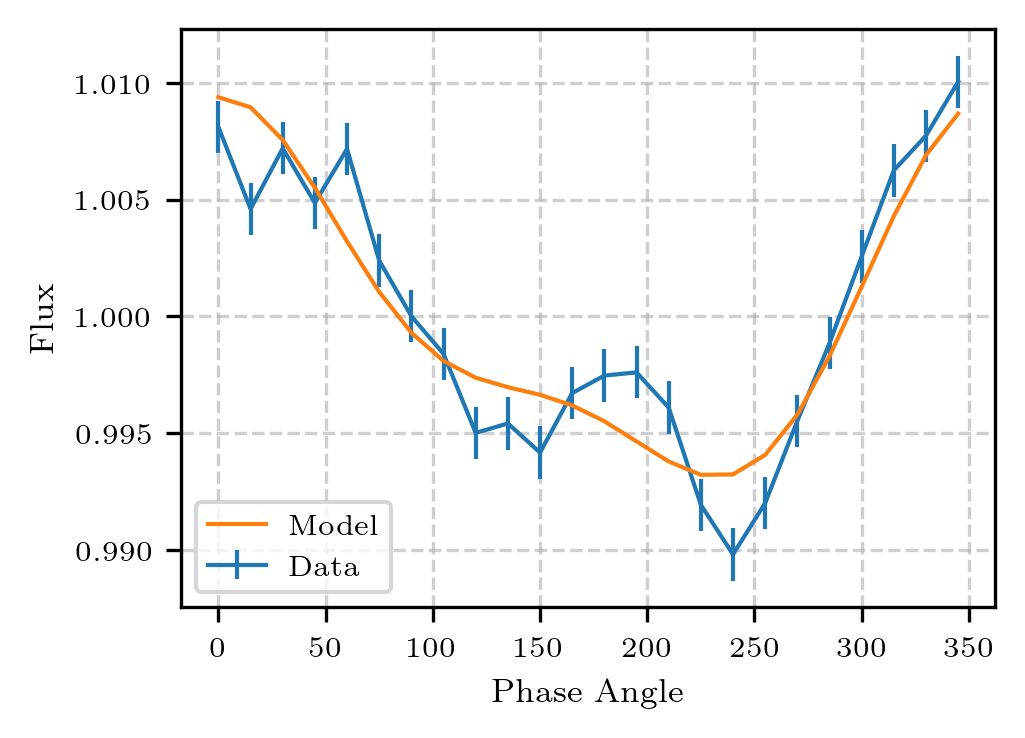

In [46]:
from spectralmap.mapping import make_map
map = make_map(mode='rotational',  map_res=30, ydeg=2, inc=80)
i_to_plot = 10  # Index of wavelength to plot
map.solve_posterior(data.flux[i_to_plot], data.flux_err[i_to_plot], data.theta, verbose=True)
map.plot_lightcurve()

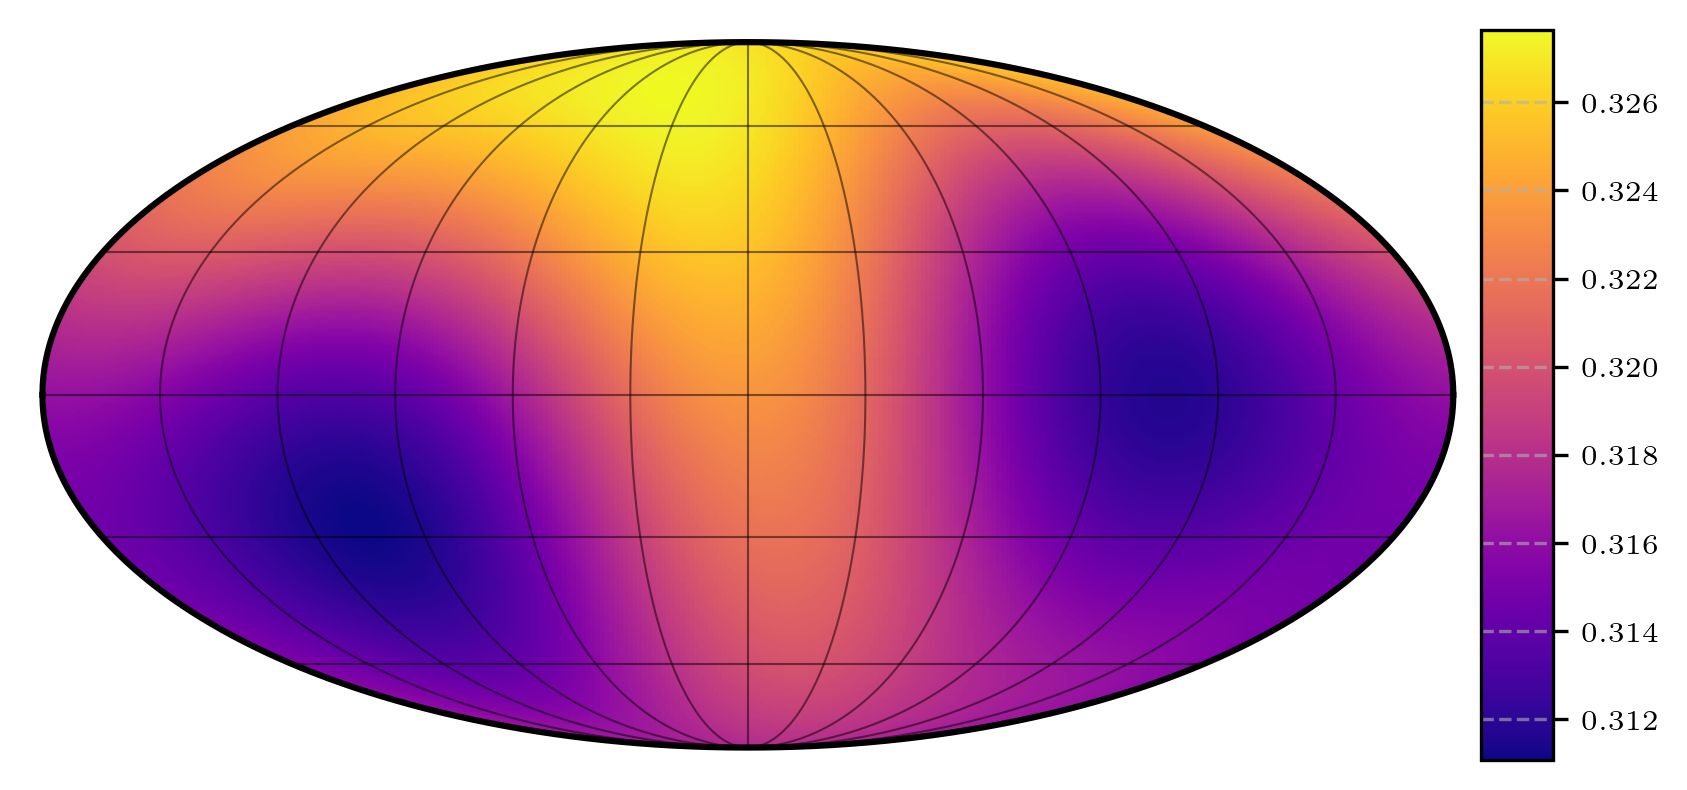

array([[ 1.00000000e+00,  8.26042305e-03,  6.61744065e-03,
        -1.34859543e-03, -3.93062330e-03, -6.67633462e-04,
         2.18509153e-03,  4.01355039e-04, -7.35837642e-03]])

In [47]:
map.draw(plot=True, projection="moll", grid=True, colorbar=True, n_samples=1)

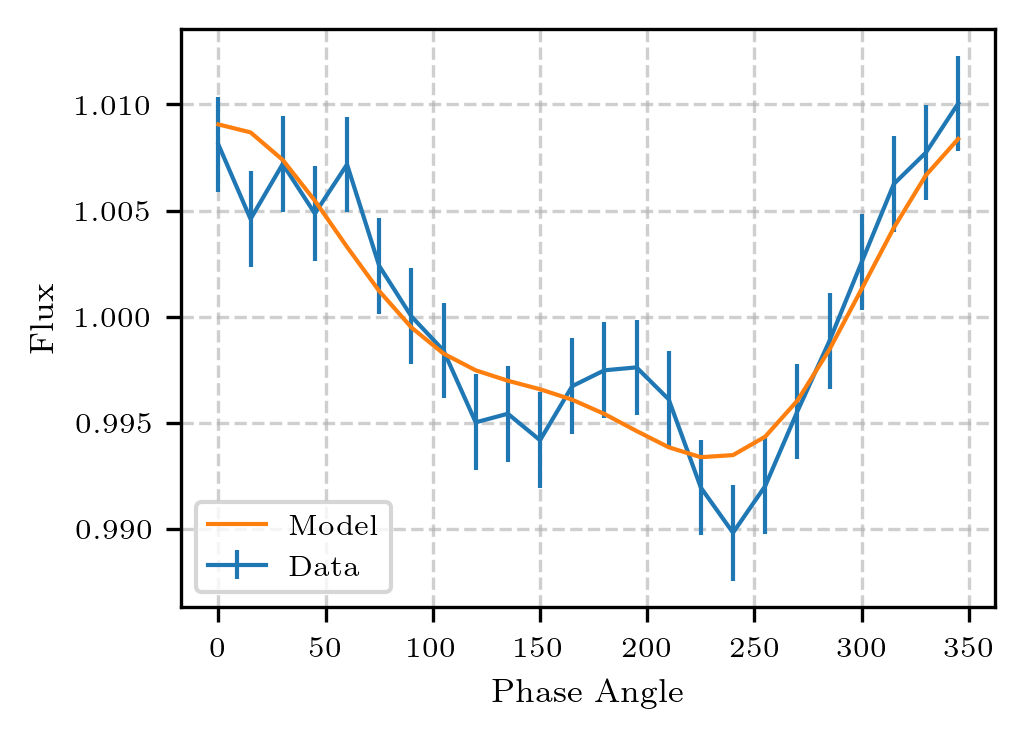

In [48]:
map.solve_posterior(data.flux[i_to_plot], None, data.theta, verbose=True)
map.plot_lightcurve()

### Find Optimal Map Complexity
We now solve for the maps. Since we don't know the complexity of the surface beforehand, we test spherical harmonic degrees ranging from `ydeg=2` to `ydeg=10`. The algorithm will automatically select the degree that best fits the data without overfitting (using the Bayesian Information Criterion).

In [49]:
# Marginalize over spherical harmonic degree to find balance model complexity and fit quality
from spectralmap.mapping import make_maps
maps = make_maps(mode='rotational', map_res=30, ydegs=np.arange(2, 10))
w_all, I_all_wl, I_cov_all_wl = maps.marginalized_maps(data)

ydeg: 100%|██████████| 8/8 [00:25<00:00,  3.22s/it, wl 359/359]


lambda=None: Best-evidence wavelength counts by ydeg: ydeg=2: 237, ydeg=3: 49, ydeg=4: 30, ydeg=5: 8, ydeg=6: 20, ydeg=7: 11, ydeg=8: 2, ydeg=9: 2


## 3. Visualize the Maps
Let's take a look at the recovered maps for a few wavelengths to see how the surface features change.

In [50]:
# for i, ydeg in enumerate(ydeg_best):
#     if ydeg <= 5:
#         plt.figure()
#         plt.imshow(I_all_wl[i].reshape((30, 30)), origin='lower')
#         plt.title(f"Wavelength {wl[i]: .2f}: best ydeg = {ydeg}")


## 4. Spectral Extraction
We convert the retrieved intensity maps ($I$) back into physical flux units ($F$) and calculate the associated variances. This gives us the spatially-resolved spectra.

In [51]:
F_all_wl = I_all_wl * amplitudes[:, None] *np.pi
F_cov_all_wl = I_cov_all_wl * (np.pi * amplitudes[:, None, None])**2
F_var_all_wl = np.diagonal(F_cov_all_wl, axis1=1, axis2=2)

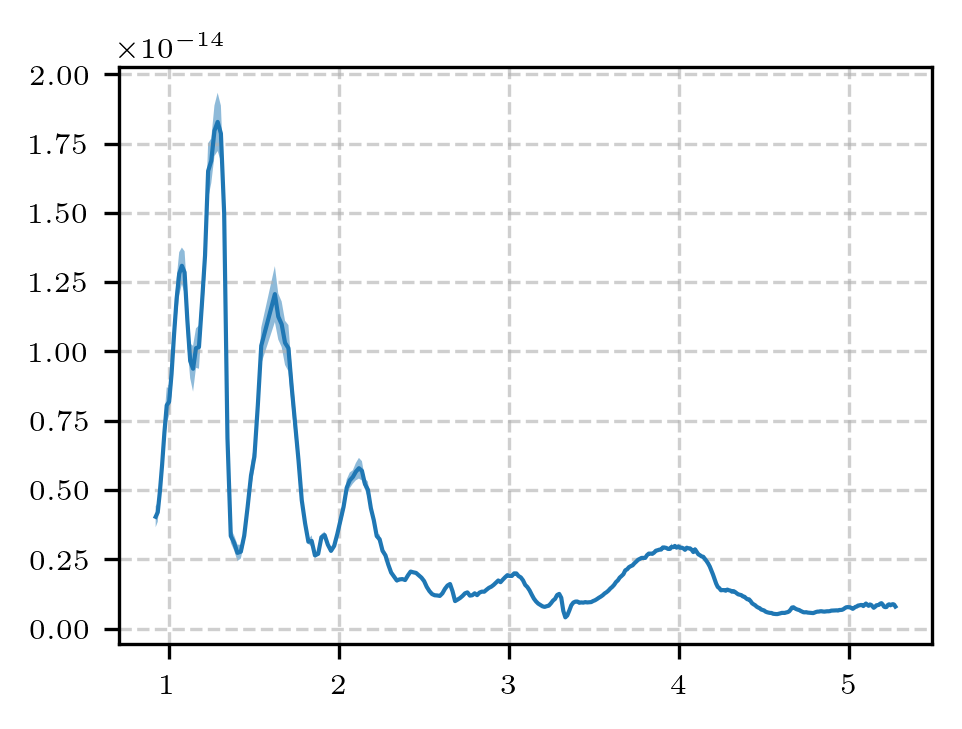

In [52]:
import matplotlib.pyplot as plt
i_grid = 300
plt.plot(wl[:], F_all_wl[:, i_grid])
plt.fill_between(wl[:], F_all_wl[:, i_grid] - np.sqrt(F_var_all_wl[:, i_grid]), F_all_wl[:, i_grid] + np.sqrt(F_var_all_wl[:, i_grid]), alpha=0.5)

## 5. Clustering and Regional Identification
To make sense of the map, we group pixels that show similar spectral behavior using a clustering algorithm. This helps us identify distinct "regions" or features on the object's surface.

In [53]:
from spectralmap.cluster import find_clusters
from sklearn.decomposition import PCA

n_neighbors = 100
n_corners = 2
F_regionals, F_regional_errs, labels = find_clusters(
    F_all_wl, F_cov_all_wl, n_neighbors=n_neighbors, n_corners=n_corners, plot=False
)
N = len(F_regionals)

# Save SIMP0136 clustering context for later two-row comparison figures
simp_n_neighbors = n_neighbors
simp_F_regionals = F_regionals.copy()
simp_F_regional_errs = F_regional_errs.copy()
simp_labels = labels.copy()
simp_N = N
simp_wl = wl.copy()
simp_flux_raw = flux_raw.copy()
simp_map_res = map.map_res
simp_moll_mask = maps.moll_mask.copy()
simp_PCs = PCA(n_components=2).fit_transform(np.log10(F_all_wl).T)
simp_cluster_names = ["Background"] + [f"Region {i+1}" for i in range(simp_N - 1)]

-1 700
0 100
1 100


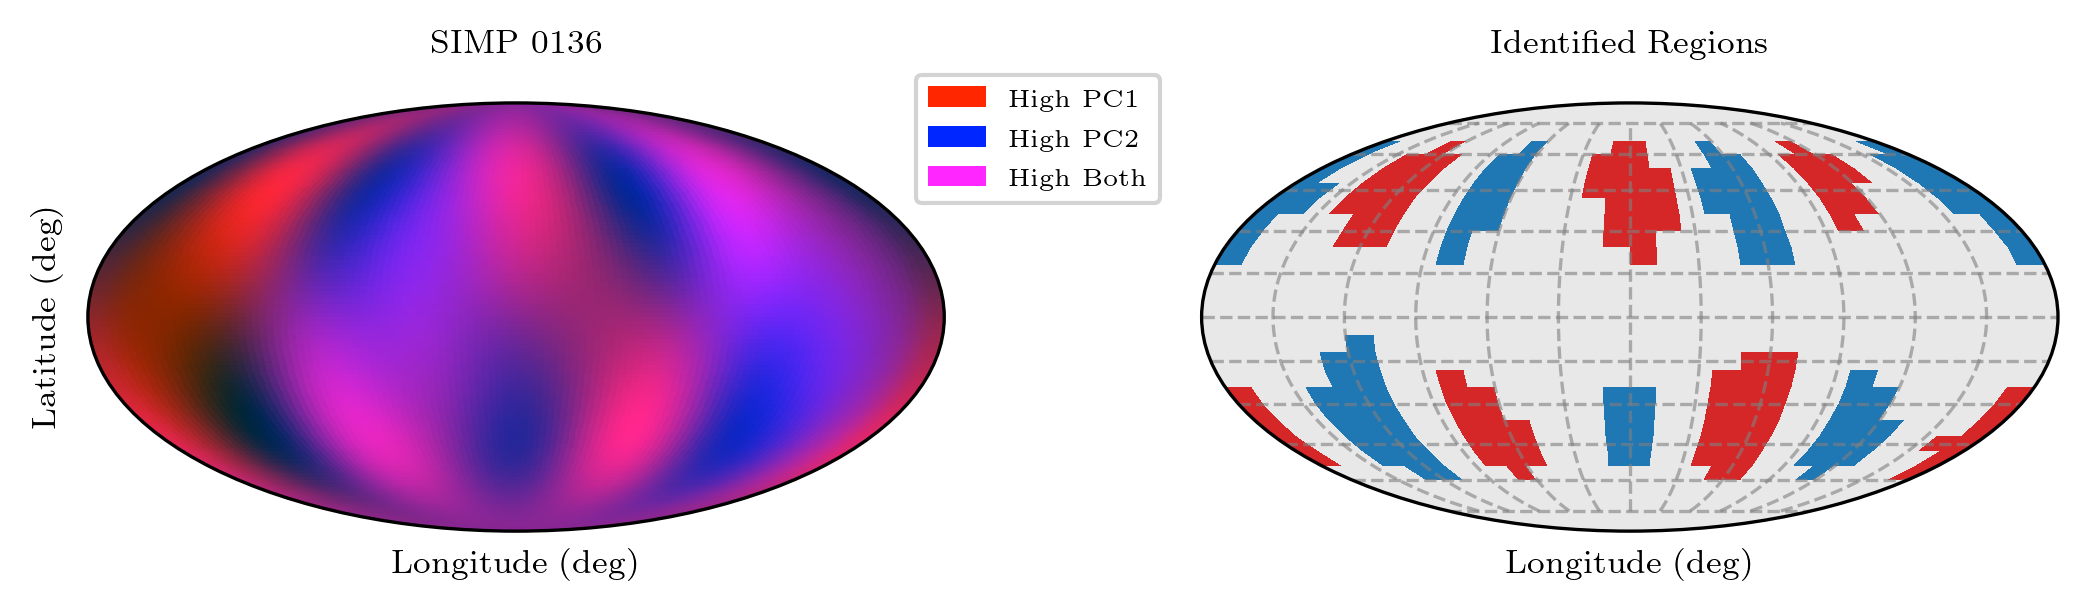

In [54]:
from sklearn.decomposition import PCA
from spectralmap.utilities import expand_moll_values
from spectralmap.plotting import plot_mollweide_rgb, plot_mollweide_labels, get_cmap

pca = PCA(n_components=2)
PCs = pca.fit_transform(np.log(F_all_wl).T)  # shape: (n_wavelengths, 2)
pc1_scores = PCs[:, 0]
pc2_scores = PCs[:, 1]

cluster_names = ["Background"] + [f"Region {i+1}" for i in range(N - 1)]
cmap = get_cmap(N)

fig, (ax_rgb, ax_lbl) = plt.subplots(
    1,
    2,
    figsize=(7, 2.5),
    subplot_kw={"projection": "mollweide"},
)

plot_mollweide_rgb(pc1_scores, pc2_scores, maps.moll_mask, upsample=4, ax=ax_rgb)
ax_rgb.set_title("SIMP 0136", pad=12)
ax_rgb.grid(alpha=0)
# Resize/reposition the existing legend created inside plot_mollweide_rgb
legend = ax_rgb.get_legend()
if legend is not None:
    legend.set_bbox_to_anchor((0.95, 1.1), transform=ax_rgb.transAxes)
    legend._loc = 2  # upper left
    legend.get_frame().set_alpha(0.85)
    for txt in legend.get_texts():
        txt.set_fontsize(6)

_, _, pcm, _ = plot_mollweide_labels(
    labels_masked=labels,      # should be ints 0..N-1 on masked pixels
    moll_mask=maps.moll_mask,
    map_res=map.map_res,
    cmap=cmap,
    names=cluster_names,
    ax=ax_lbl,
    add_colorbar=False,
)
ax_lbl.set_title("Identified Regions", pad=12)

for ax in (ax_rgb, ax_lbl):
    ax.set_xlabel("Longitude (deg)")
ax_rgb.set_ylabel("Latitude (deg)")
ax_lbl.set_ylabel("")
ax_lbl.set_yticklabels([])

plt.tight_layout()
plt.savefig(PAPER_FIGURES_DIR+'S0136_identified_regions.pdf', dpi=300)

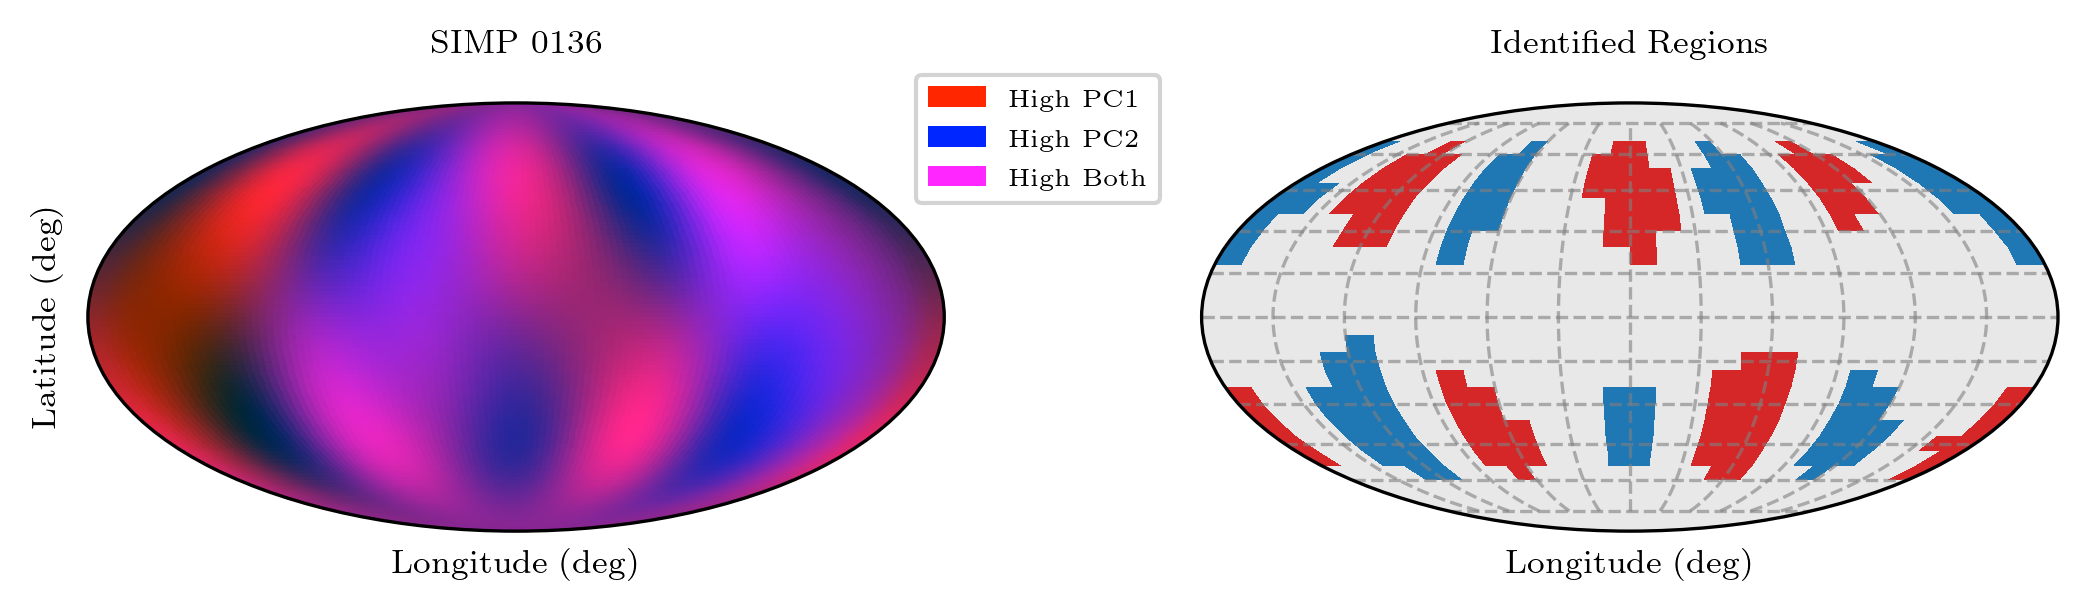

In [55]:
from sklearn.decomposition import PCA
from spectralmap.utilities import expand_moll_values
from spectralmap.plotting import plot_mollweide_rgb, plot_mollweide_labels, get_cmap

pca = PCA(n_components=2)
PCs = pca.fit_transform(np.log(F_all_wl).T)  # shape: (n_wavelengths, 2)
pc1_scores = PCs[:, 0]
pc2_scores = PCs[:, 1]

cluster_names = ["Background"] + [f"Region {i+1}" for i in range(N - 1)]
cmap = get_cmap(N)

fig, (ax_rgb, ax_lbl) = plt.subplots(
    1,
    2,
    figsize=(7, 2.5),
    subplot_kw={"projection": "mollweide"},
)

plot_mollweide_rgb(pc1_scores, pc2_scores, maps.moll_mask, upsample=4, ax=ax_rgb)
ax_rgb.set_title("SIMP 0136", pad=12)
ax_rgb.grid(alpha=0)
# Resize/reposition the existing legend created inside plot_mollweide_rgb
legend = ax_rgb.get_legend()
if legend is not None:
    legend.set_bbox_to_anchor((0.95, 1.1), transform=ax_rgb.transAxes)
    legend._loc = 2  # upper left
    legend.get_frame().set_alpha(0.85)
    for txt in legend.get_texts():
        txt.set_fontsize(6)

_, _, pcm, _ = plot_mollweide_labels(
    labels_masked=labels,      # should be ints 0..N-1 on masked pixels
    moll_mask=maps.moll_mask,
    map_res=map.map_res,
    cmap=cmap,
    names=cluster_names,
    ax=ax_lbl,
    add_colorbar=False,
)
ax_lbl.set_title("Identified Regions", pad=12)

for ax in (ax_rgb, ax_lbl):
    ax.set_xlabel("Longitude (deg)")
ax_rgb.set_ylabel("Latitude (deg)")
ax_lbl.set_ylabel("")
ax_lbl.set_yticklabels([])

plt.tight_layout()
plt.savefig(PAPER_FIGURES_DIR+'S0136_identified_regions.pdf', dpi=300)

## 6. Results
Finally, we visualize the identified clusters on the map and plot the mean spectrum for each region.

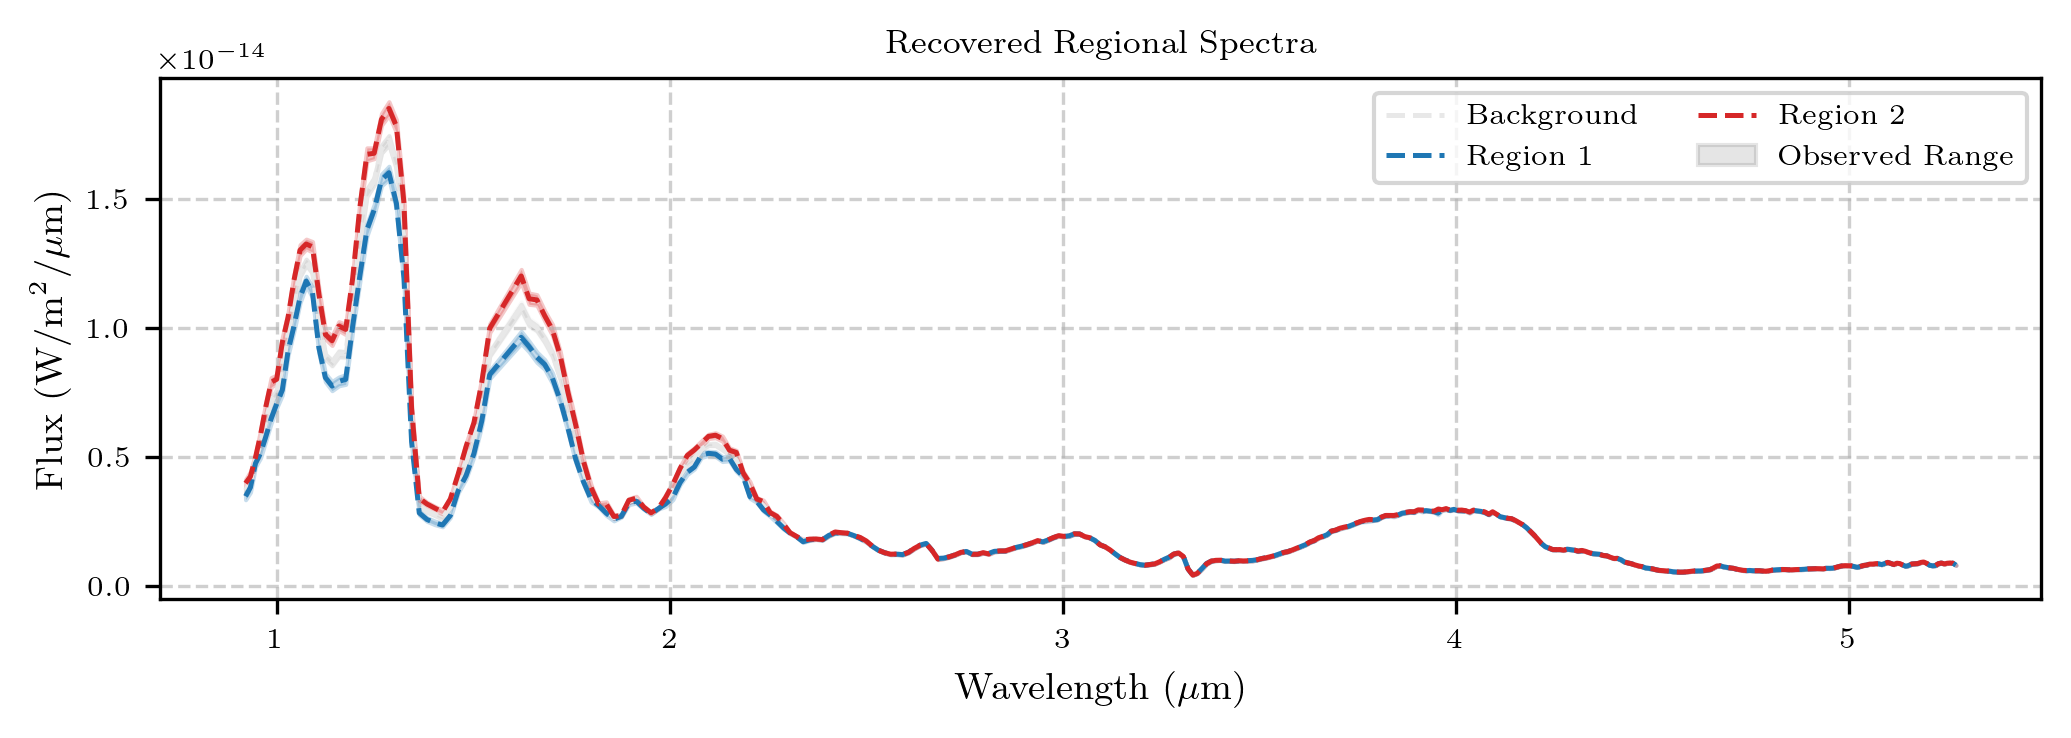

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr

fig, ax = plt.subplots(figsize=(7, 2.5))

color_list = COLOR_LIST[:N]

# Plot the recovered spectra for each region
for i in range(N):
    mean_flux = F_regionals[i]
    error_flux = F_regional_errs[i] # Fixed variable name
    color = color_list[i]
    label = cluster_names[i]
    
    ax.plot(wl, mean_flux, label=f"{label}", color=color, linewidth=1.2, linestyle='--')
    ax.fill_between(wl, 
                    mean_flux - error_flux, 
                    mean_flux + error_flux, 
                    alpha=0.25, color=color)
    
# Overlay the range of the observed time-series variability
time_series = np.sort(flux_raw.T, axis=0)
ax.fill_between(wl, time_series[0, :],
            time_series[-1, :], color='black', alpha=0.10, zorder=0, label="Observed Range")

# Formatting
ax.set_xlabel(r"Wavelength ($\mu$m)", fontsize=9)
ax.set_ylabel(r"Flux (W/m$^2$/$\mu$m)", fontsize=9)
ax.set_title("Recovered Regional Spectra")
ax.legend(loc='upper right', ncol=2)
# ax.set_xscale("log")
plt.tight_layout()
output_path = PAPER_FIGURES_DIR + "S0136_recovered_spectra.pdf"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

In [57]:
Fp_final = F_regionals[1:] # = np.vstack([X[i_max_1D], X[i_min_1D], X.mean(axis=0)])
N = len(Fp_final)
wl_final = np.tile(wl, N)
noise_final = F_regional_errs[1:]
Fp_final = Fp_final.reshape(-1)
noise_final = noise_final.reshape(-1)
import pandas as pd
output_df = pd.DataFrame(
    data=np.array([wl_final, Fp_final, noise_final]).T
)  # for petitradtrans
output_df.to_csv(
    "./NIRSPEC_S0136_2_clusters_08_50.dat", sep=" ", header=False, index=False
)

Fp_final = F_regionals[1:] # = np.vstack([X[i_max_1D], X[i_min_1D], X.mean(axis=0)])
noise_final = F_regional_errs[1:]

for i in range(N):
    output_df = pd.DataFrame(
        data=np.array([wl, Fp_final[i], noise_final[i]]).T
    )  # for petitradtrans
    output_df.to_csv(
        f"./NIRSPEC_S0136_cluster_{i+1}_08_50.dat", sep=" ", header=False, index=False
)

# Keep SIMP0136 variables available after running the Luhman 16B section
simp_F_regionals = F_regionals.copy()
simp_F_regional_errs = F_regional_errs.copy()
simp_cluster_names = list(cluster_names)
simp_wl = wl.copy()
simp_flux_raw = flux_raw.copy()

# Demo: Mapping Luhman 16B with NIRSpec

In this tutorial, we will demonstrate how to use `spectralmap` to analyze time-series observations. We will use a sequence of NIRSpec observations of the brown dwarf Luhman 16B to recover a spectroscopic map of its surface.

**We will cover:**
1. Loading and preprocessing the lightcurve data.
2. Inverting the lightcurves to obtain surface maps.
3. Clustering the map pixels to identify distinct spectral regions.
4. Extracting and analyzing the spectra of these regions.

Let's get started!

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from spectralmap.utilities import bin_flux_by_theta
from spectralmap.plotting import COLOR_LIST, PAPER_FIGURES_DIR

## 1. Load Data
We load the NIRSpec lightcurve files. Each file corresponds to a specific rotation phase (angle). We will read them in, sort them by phase, and normalize the flux.

In [59]:
import numpy as np
from spectralmap.utilities import bin_flux_by_theta

# 1. Load the data files
data_file = "data/Luhman16B_NIRSpec_2023.npz"
theta = np.load(data_file)["theta"]
wl = np.load(data_file)["wl"]
flux_raw = np.load(data_file)["flux_raw"]

amplitudes = np.nanmean(flux_raw, axis=1)
flux = (flux_raw.T / amplitudes).T

theta, flux, flux_err, counts = bin_flux_by_theta(theta, flux, n_bins=64, flux_err=None)

## 2. Inversion with SpectralMap

First, we organize the data into a `LightCurveData` object. We must specify the inclination of the object (here assumed to be 80 degrees).

In [60]:
from spectralmap.mapping import LightCurveData, make_map
data = LightCurveData(theta=theta, flux=flux, flux_err=None, inc=90)

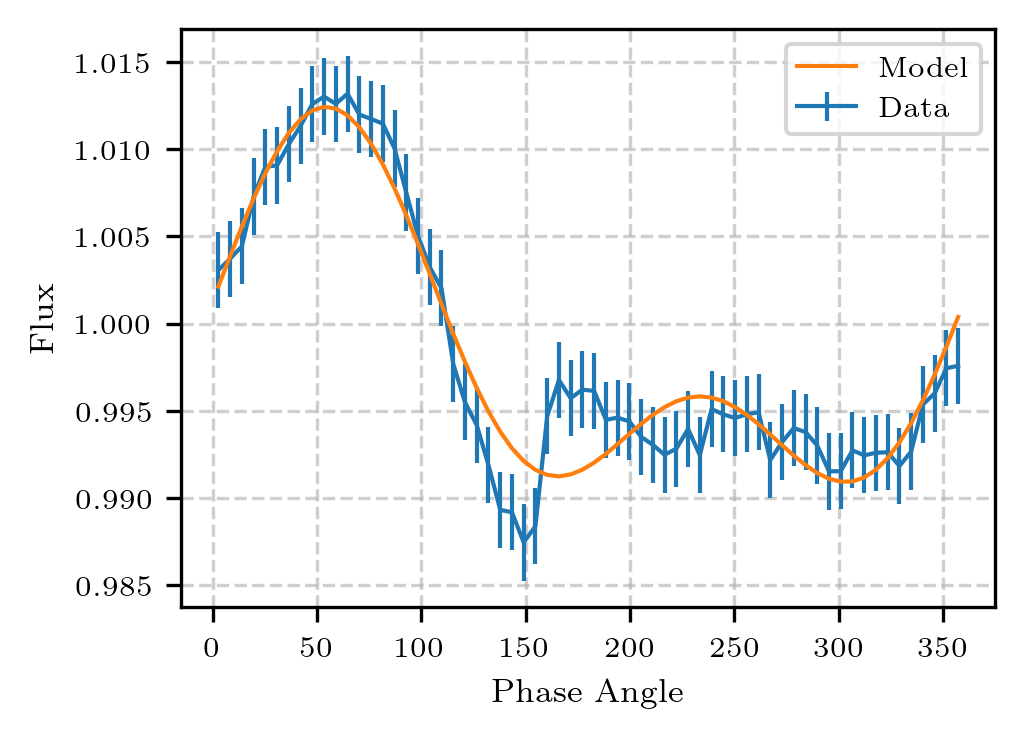

In [61]:
wl_test = 4.5
i_wl = np.argmin(np.abs(wl - wl_test))
map = make_map(mode='rotational', map_res=30, ydeg=2, inc=90)
map.solve_posterior(data.flux[i_wl], None, data.theta, verbose=False)
map.plot_lightcurve()

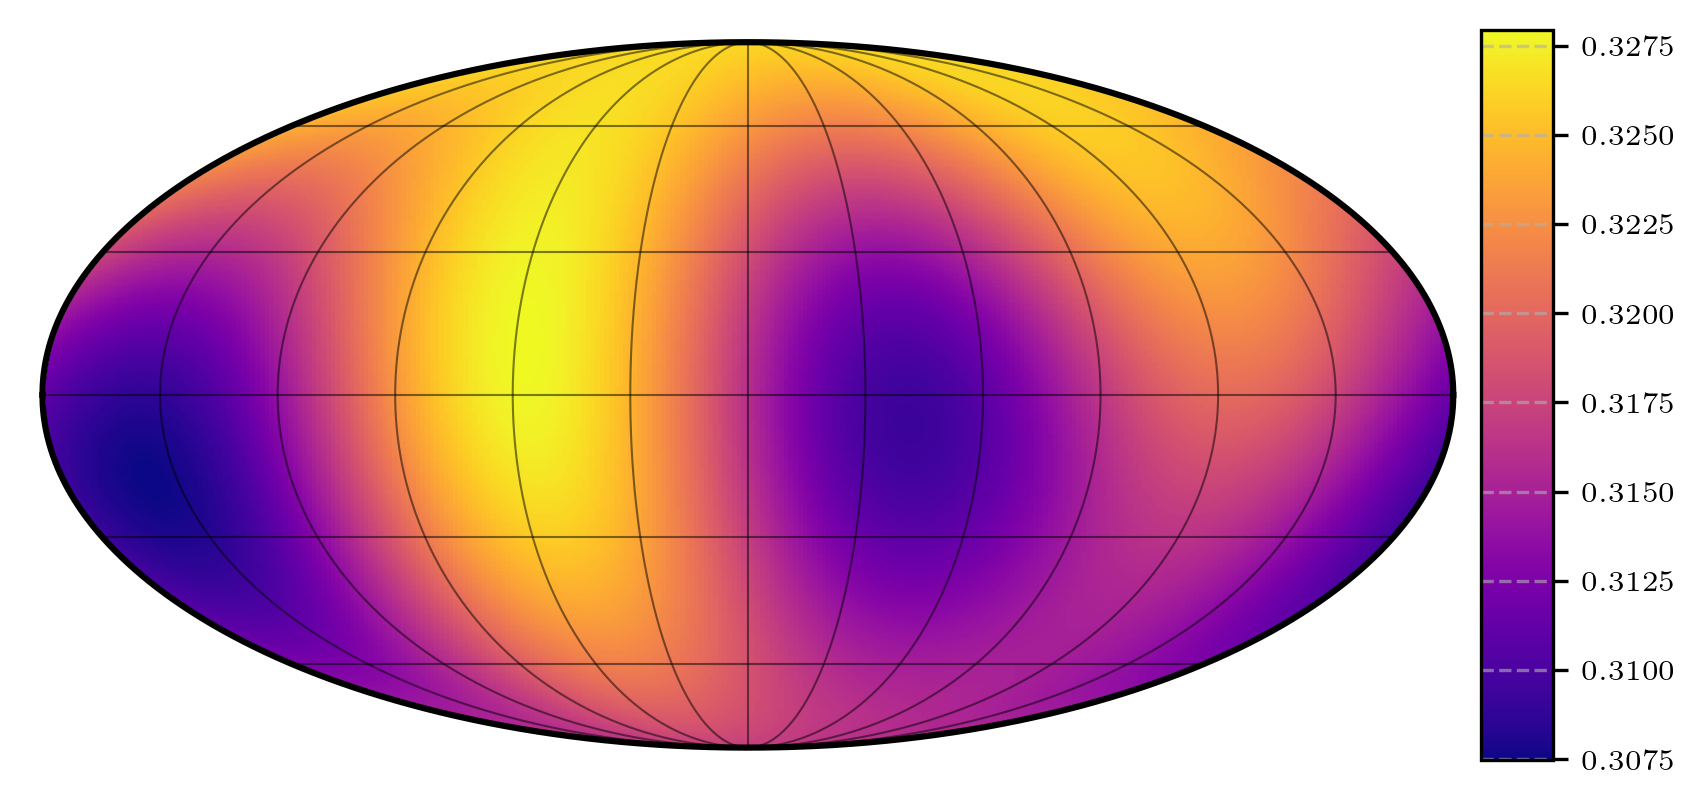

In [62]:
_ = map.draw(plot=True, projection="moll", grid=True, colorbar=True, n_samples=1)

### Find Optimal Map Complexity
We now solve for the maps. Since we don't know the complexity of the surface beforehand, we test spherical harmonic degrees ranging from `ydeg=2` to `ydeg=10`. The algorithm will automatically select the degree that best fits the data without overfitting (using the Bayesian Information Criterion).

In [63]:
from spectralmap.mapping import make_maps
maps = make_maps(mode='rotational', map_res=30, ydegs=np.arange(2, 10))

In [64]:
# Solve for the best spherical harmonic degree (ydeg) for each wavelength
# This optimizes the model complexity (model evidence) to avoid overfitting
w_all, I_all_wl, I_cov_all_wl = maps.marginalized_maps(data)

ydeg: 100%|██████████| 4/4 [00:05<00:00,  1.32s/it, wl 334/334]


lambda=None: Best-evidence wavelength counts by ydeg: ydeg=2: 12, ydeg=4: 273, ydeg=6: 49, ydeg=8: 0


## 3. Visualize the Maps
Let's take a look at the recovered maps for a few wavelengths to see how the surface features change.

In [65]:
# for i, ydeg in enumerate(ydeg_best[:10]):
#     if ydeg <= 5:
#         plt.figure()
#         plt.imshow(I_all_wl[i].reshape((30, 30)), origin='lower')
#         plt.title(f"Wavelength {wl[i]: .2f}: best ydeg = {ydeg}")

## 4. Spectral Extraction
We convert the retrieved intensity maps ($I$) back into physical flux units ($F$) and calculate the associated variances. This gives us the spatially-resolved spectra.

In [66]:
F_all_wl = I_all_wl * amplitudes[:, None] *np.pi
F_cov_all_wl = I_cov_all_wl * (np.pi * amplitudes[:, None, None])**2
F_var_all_wl = np.diagonal(F_cov_all_wl, axis1=1, axis2=2)

In [67]:
from spectralmap.mapping import expand_moll_values
F_all_wl_grid = expand_moll_values(F_all_wl, maps.moll_mask_flat)
F_var_all_wl_grid = expand_moll_values(F_var_all_wl, maps.moll_mask_flat)

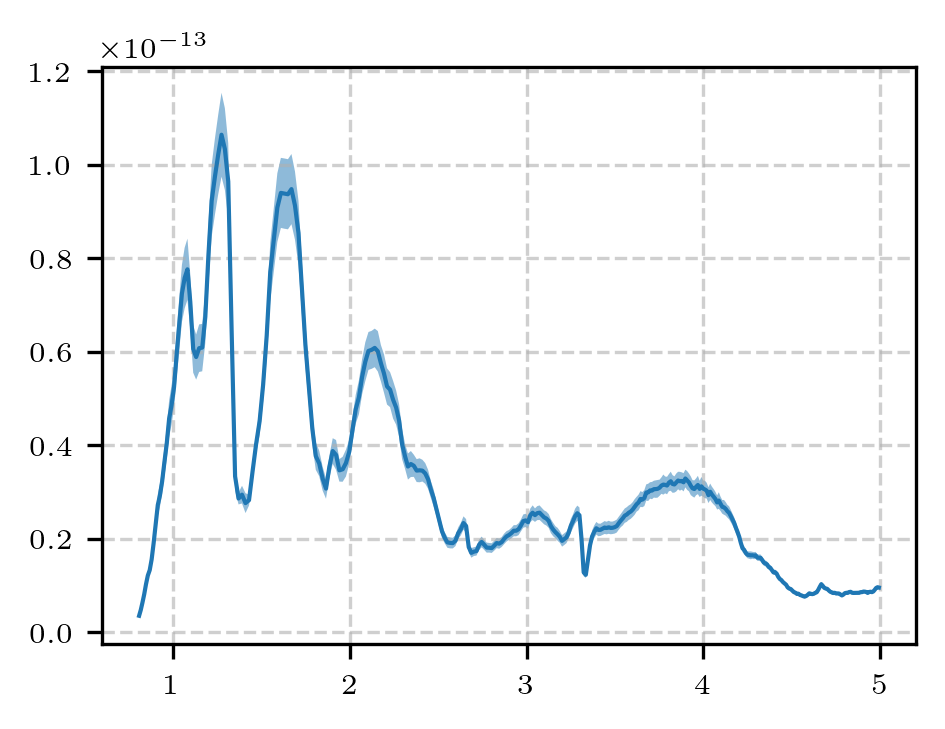

In [68]:
import matplotlib.pyplot as plt
i_grid = -1
plt.plot(wl[:], F_all_wl[:, i_grid])
plt.fill_between(wl[:], F_all_wl[:, i_grid] - np.sqrt(F_var_all_wl[:, i_grid]), F_all_wl[:, i_grid] + np.sqrt(F_var_all_wl[:, i_grid]), alpha=0.5)

## 5. Clustering and Regional Identification
To make sense of the map, we group pixels that show similar spectral behavior using a clustering algorithm. This helps us identify distinct "regions" or features on the object's surface.

In [69]:
from spectralmap.cluster import find_clusters
from sklearn.decomposition import PCA

n_neighbors = 100
n_corners = 3
F_regionals, F_regional_errs, labels = find_clusters(
    F_all_wl, F_cov_all_wl, n_neighbors=n_neighbors, n_corners=n_corners, plot=False
)
N = len(F_regionals)

# Save Luhman 16B clustering context
luh_n_neighbors = n_neighbors
luh_F_regionals = F_regionals.copy()
luh_F_regional_errs = F_regional_errs.copy()
luh_labels = labels.copy()
luh_N = N
luh_wl = wl.copy()
luh_flux_raw = flux_raw.copy()
luh_map_res = map.map_res
luh_moll_mask = maps.moll_mask.copy()
luh_PCs = PCA(n_components=2).fit_transform(np.log10(F_all_wl).T)
luh_cluster_names = ["Background"] + [f"Region {i+1}" for i in range(luh_N - 1)]

-1 600
0 100
1 100
2 100


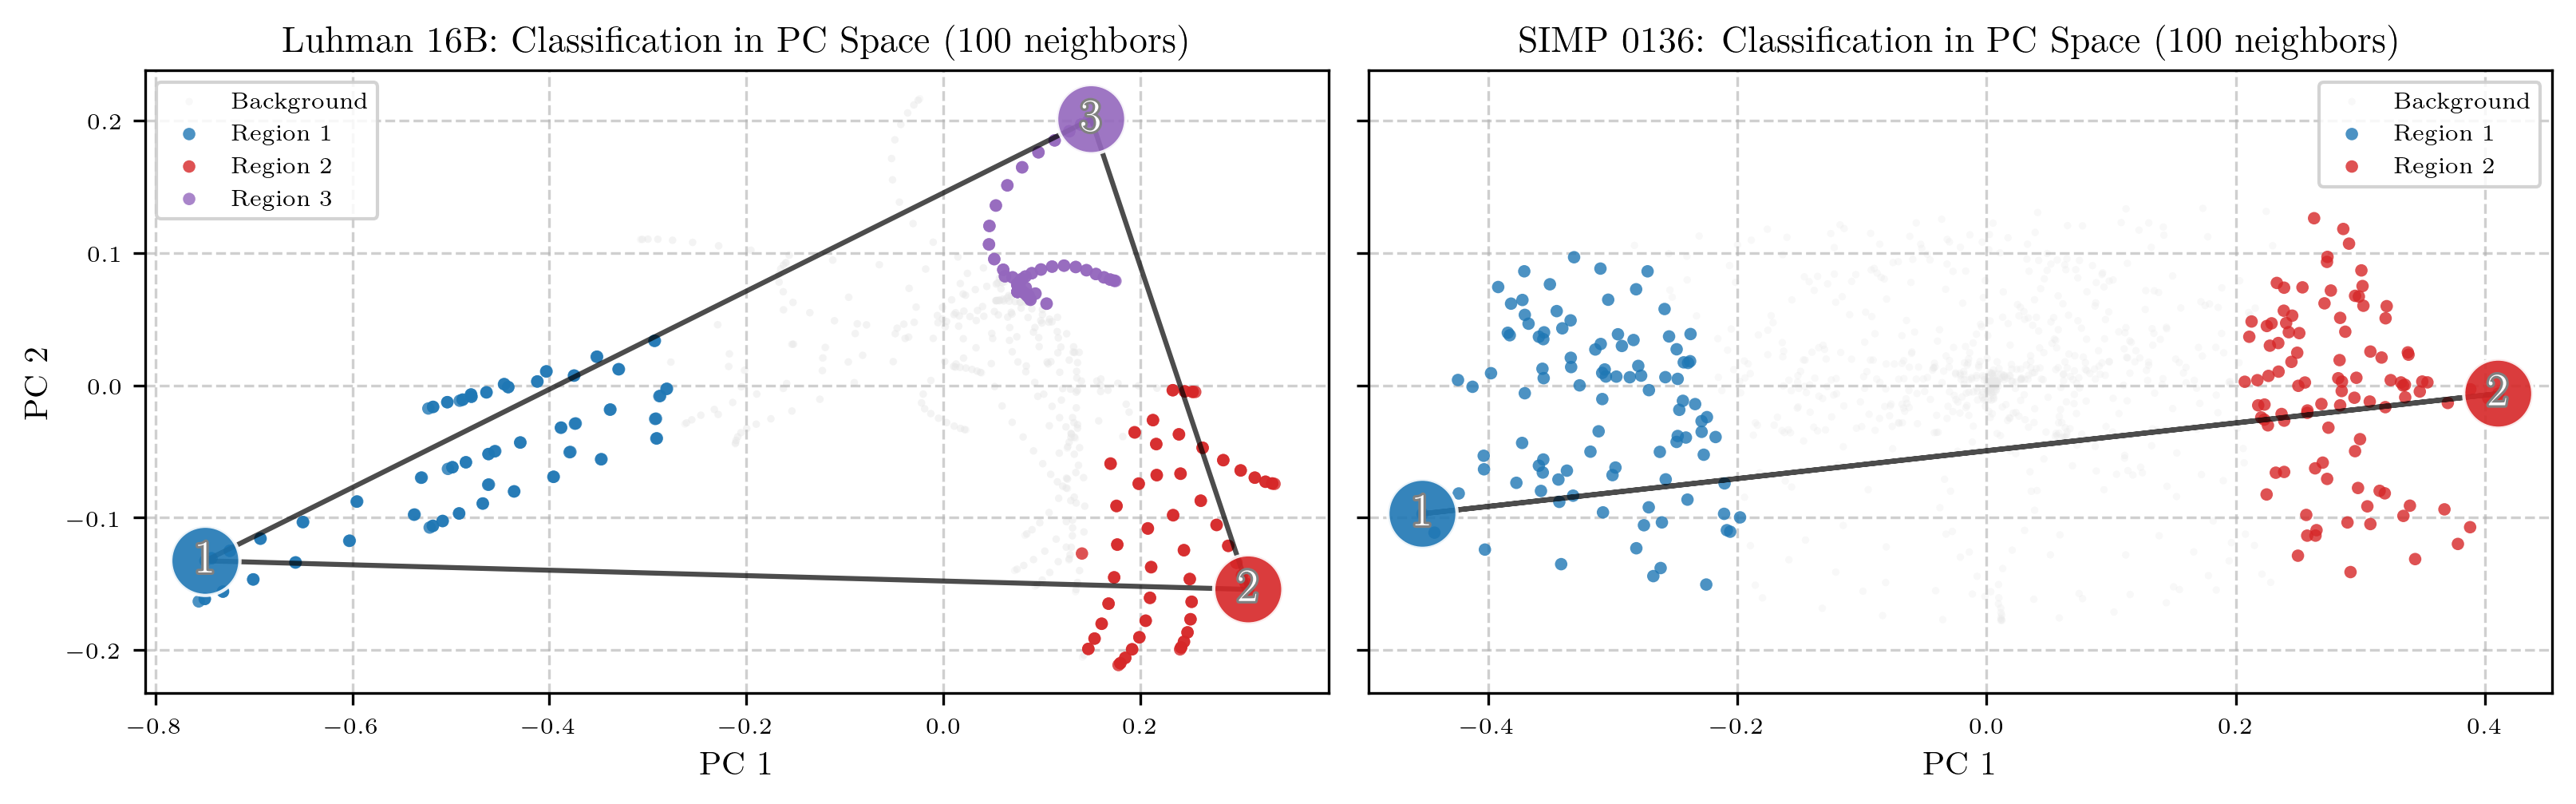

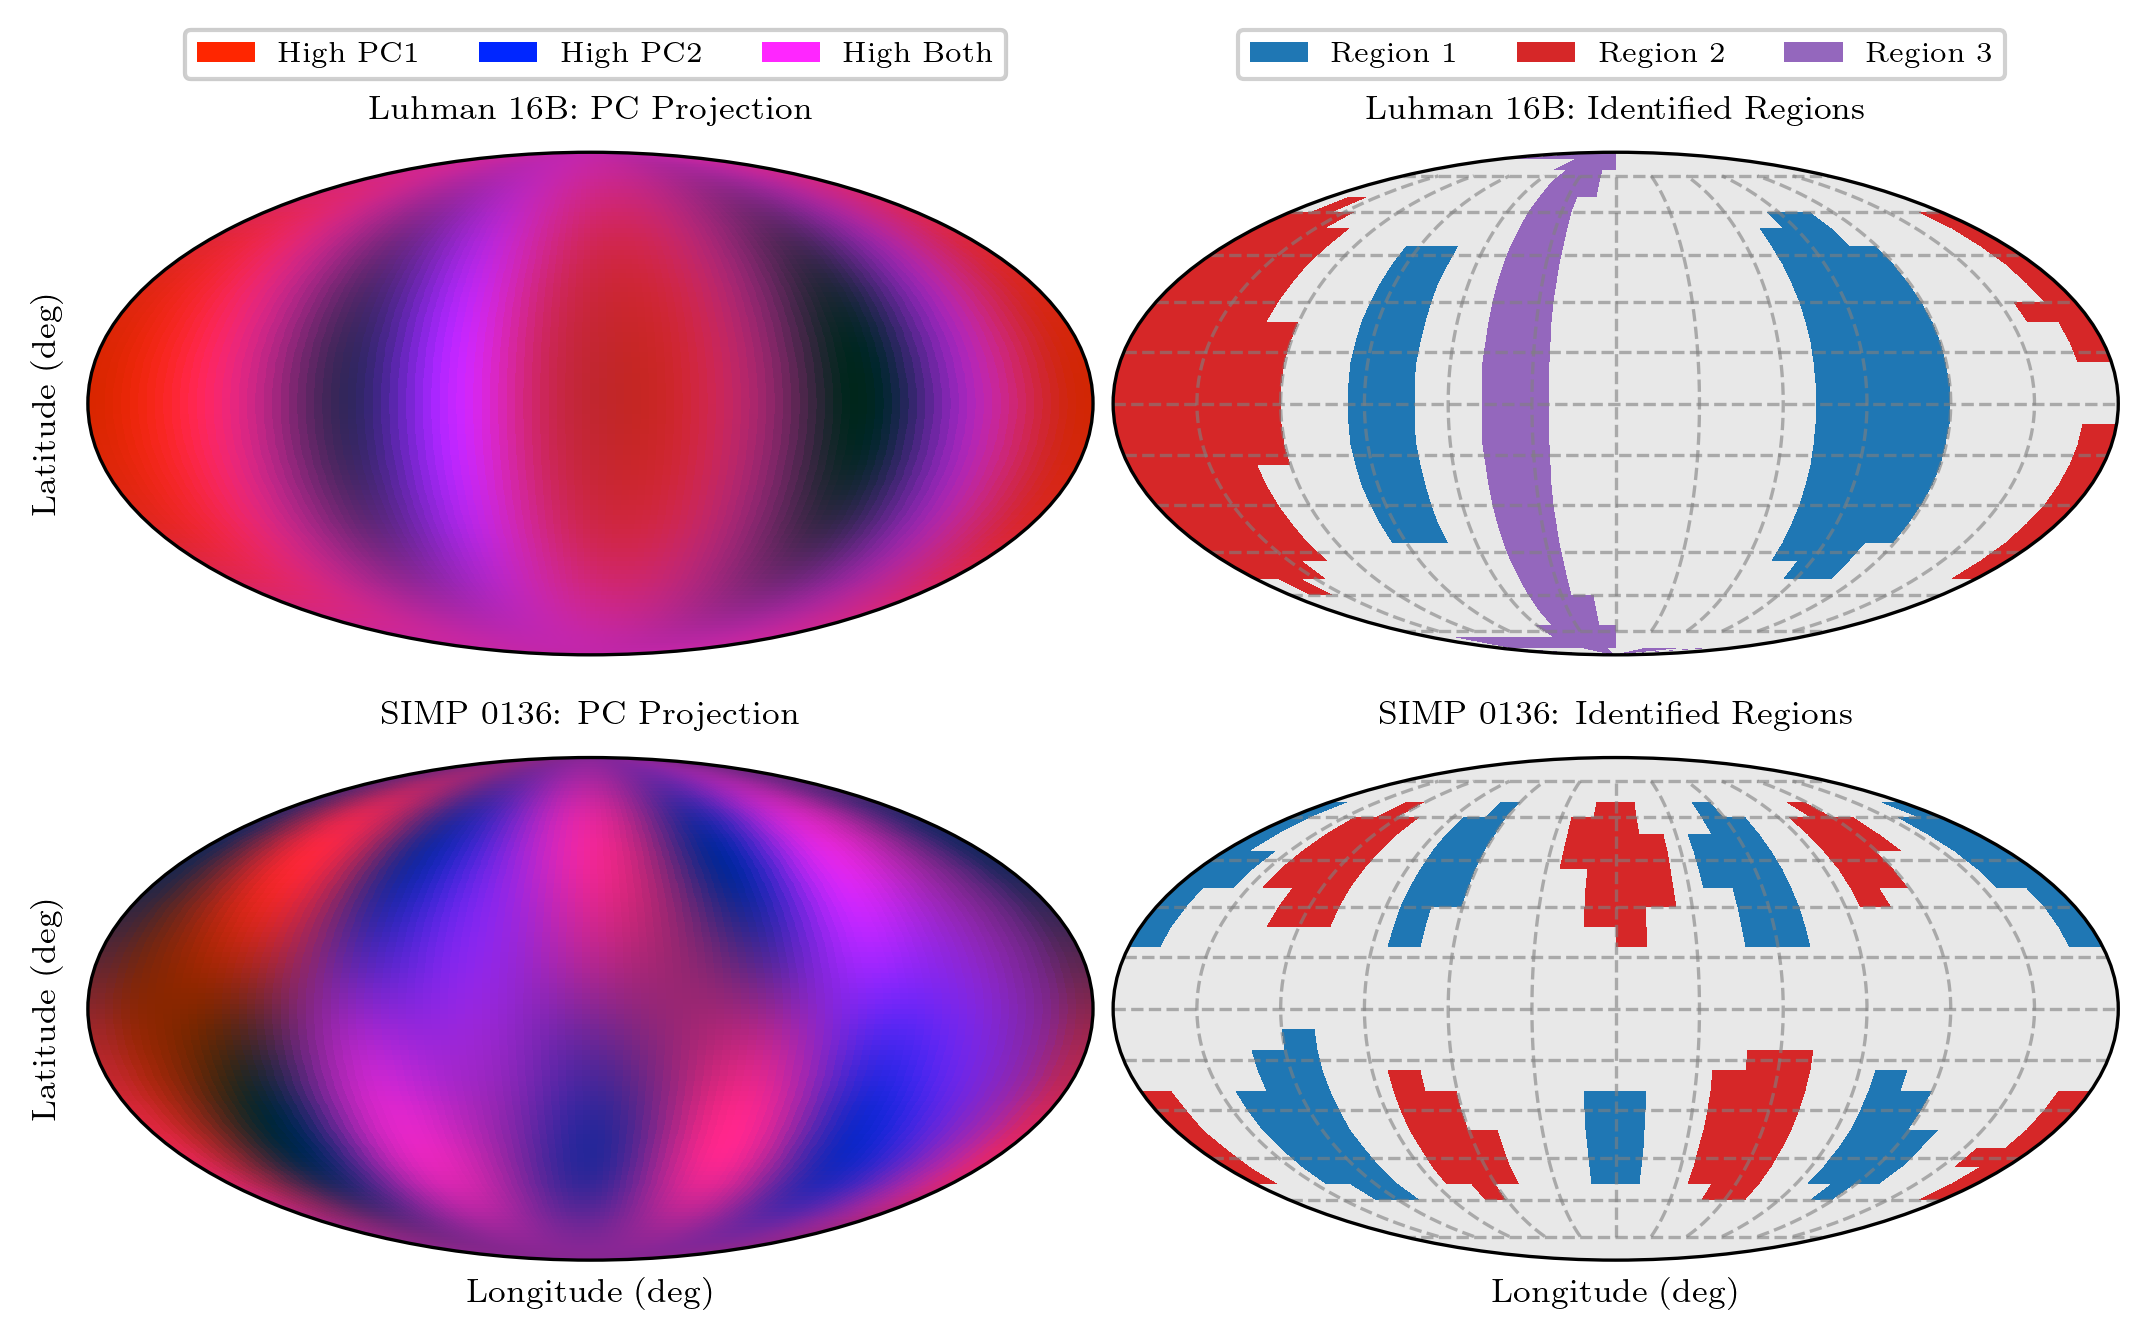

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from spectralmap.cluster import get_best_polygon
from spectralmap.plotting import plot_mollweide_rgb, plot_mollweide_labels, get_cmap

def _pc_anchor_geometry(PCs_obj, n_regions):
    if n_regions == 2:
        W_centered = PCs_obj - np.mean(PCs_obj, axis=0)
        _, _, vh = np.linalg.svd(W_centered, full_matrices=False)
        max_var_dir = vh[0]
        proj = W_centered @ max_var_dir
        corner_indices = np.array([int(np.argmin(proj)), int(np.argmax(proj))], dtype=int)
        corner_coords = PCs_obj[corner_indices]
    else:
        corner_indices = get_best_polygon(PCs_obj, n_corners=n_regions)
        corner_coords = PCs_obj[corner_indices]

    centroid = np.mean(corner_coords, axis=0)
    angles = np.arctan2(corner_coords[:, 1] - centroid[1], corner_coords[:, 0] - centroid[0])
    sort_order = np.argsort(angles)
    corner_coords = corner_coords[sort_order]
    centers = corner_coords[:, :2]
    return corner_coords, centers

# -----------------------------
# Combined PC-space classification (1 row x 2 cols)
# -----------------------------
fig_pc, axs_pc = plt.subplots(1, 2, figsize=(10.8, 3.4), sharey=True)

for ax, title, PCs_obj, labels_obj, n_neighbors_obj, N_obj in [
    (axs_pc[0], "Luhman 16B", luh_PCs, luh_labels, luh_n_neighbors, luh_N),
    (axs_pc[1], "SIMP 0136", simp_PCs, simp_labels, simp_n_neighbors, simp_N),
]:
    K_obj = N_obj - 1
    corner_coords, centers = _pc_anchor_geometry(PCs_obj, K_obj)

    mask_unassigned = labels_obj == -1
    ax.scatter(
        PCs_obj[mask_unassigned, 0], PCs_obj[mask_unassigned, 1],
        s=5, alpha=0.3, color=COLOR_LIST[0], edgecolor="none", zorder=1, label="Background",
    )

    for k in range(K_obj):
        mask_k = labels_obj == k
        color = COLOR_LIST[(k + 1) % len(COLOR_LIST)]
        ax.scatter(
            PCs_obj[mask_k, 0], PCs_obj[mask_k, 1],
            s=14, alpha=0.8, color=color, edgecolor="none", zorder=2, label=f"Region {k+1}",
        )

    # Polygon and region-number labels matching find_clusters style
    poly_draw = np.vstack([corner_coords, corner_coords[0]])
    ax.plot(poly_draw[:, 0], poly_draw[:, 1], "k-", lw=1.5, alpha=0.7, zorder=3)

    for k in range(K_obj):
        color = COLOR_LIST[(k + 1) % len(COLOR_LIST)]
        ax.text(
            centers[k, 0], centers[k, 1], f"{k+1}",
            fontsize=14, fontweight="bold", color="white",
            ha="center", va="center",
            bbox=dict(boxstyle="circle,pad=0.3", facecolor=color, edgecolor="white", linewidth=1, alpha=0.9),
            path_effects=[pe.Stroke(linewidth=1.5, foreground="gray"), pe.Normal()],
            zorder=10,
        )

    ax.set_title(f"{title}: Classification in PC Space ({n_neighbors_obj} neighbors)", fontsize=11)
    ax.set_aspect("auto")
    ax.legend(loc="best", framealpha=0.85)

axs_pc[0].set_xlabel("PC 1", fontsize=10)
axs_pc[1].set_xlabel("PC 1", fontsize=10)
axs_pc[0].set_ylabel("PC 2", fontsize=10)
fig_pc.tight_layout()
fig_pc.savefig(PAPER_FIGURES_DIR + "Luhman16B_S0136_pc_space_classification_combined.pdf", dpi=300)

# -----------------------------
# Combined identified regions (2 rows x 2 cols)
# -----------------------------
fig_reg = plt.figure(figsize=(7.2, 4.9))
gs = fig_reg.add_gridspec(2, 2, width_ratios=[1.0, 1.0], wspace=0.02, hspace=-0.3)

ax_luh_rgb = fig_reg.add_subplot(gs[0, 0], projection="mollweide")
ax_luh_lbl = fig_reg.add_subplot(gs[0, 1], projection="mollweide")
ax_simp_rgb = fig_reg.add_subplot(gs[1, 0], projection="mollweide")
ax_simp_lbl = fig_reg.add_subplot(gs[1, 1], projection="mollweide")

plot_mollweide_rgb(luh_PCs[:, 0], luh_PCs[:, 1], luh_moll_mask, upsample=4, ax=ax_luh_rgb)
ax_luh_rgb.set_title("Luhman 16B: PC Projection", pad=8)
ax_luh_rgb.grid(alpha=0)
legend = ax_luh_rgb.get_legend()
if legend is not None:
    legend.remove()

_, _, _, _ = plot_mollweide_labels(
    labels_masked=luh_labels,
    moll_mask=luh_moll_mask,
    map_res=luh_map_res,
    cmap=get_cmap(luh_N),
    names=luh_cluster_names,
    ax=ax_luh_lbl,
    add_colorbar=False,
)
ax_luh_lbl.set_title("Luhman 16B: Identified Regions", pad=8)

plot_mollweide_rgb(simp_PCs[:, 0], simp_PCs[:, 1], simp_moll_mask, upsample=4, ax=ax_simp_rgb)
ax_simp_rgb.set_title("SIMP 0136: PC Projection", pad=8)
ax_simp_rgb.grid(alpha=0)
legend = ax_simp_rgb.get_legend()
if legend is not None:
    legend.remove()

_, _, _, _ = plot_mollweide_labels(
    labels_masked=simp_labels,
    moll_mask=simp_moll_mask,
    map_res=simp_map_res,
    cmap=get_cmap(simp_N),
    names=simp_cluster_names,
    ax=ax_simp_lbl,
    add_colorbar=False,
)
ax_simp_lbl.set_title("SIMP 0136: Identified Regions", pad=8)

pc_legend_elements = [
    Patch(facecolor=(1.0, 0.15, 0.0), label="High PC1"),
    Patch(facecolor=(0.0, 0.15, 1.0), label="High PC2"),
    Patch(facecolor=(1.0, 0.15, 1.0), label="High Both"),
]
pc_legend = fig_reg.legend(
    handles=pc_legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.275, 0.97),
    ncol=3,
    framealpha=0.9,
)

region_legend_elements = [
    Patch(facecolor=COLOR_LIST[1], label="Region 1"),
    Patch(facecolor=COLOR_LIST[2], label="Region 2"),
    Patch(facecolor=COLOR_LIST[3], label="Region 3"),
]
region_legend = fig_reg.legend(
    handles=region_legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.75, 0.97),
    ncol=3,
    framealpha=0.9,
)
fig_reg.add_artist(pc_legend)

for ax in (ax_luh_rgb, ax_luh_lbl, ax_simp_rgb, ax_simp_lbl):
    ax.set_xlabel("")

for ax in (ax_simp_rgb, ax_simp_lbl):
    ax.set_xlabel("Longitude (deg)")
ax_luh_rgb.set_ylabel("Latitude (deg)")
ax_simp_rgb.set_ylabel("Latitude (deg)")
ax_luh_lbl.set_ylabel("")
ax_simp_lbl.set_ylabel("")
ax_luh_lbl.set_yticklabels([])
ax_simp_lbl.set_yticklabels([])

fig_reg.subplots_adjust(left=0.04, right=0.98, top=1, bottom=0, wspace=0.0, hspace=0.0)
fig_reg.savefig(
    PAPER_FIGURES_DIR + "Luhman16B_S0136_identified_regions_combined.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.01,
)

## 6. Results
Finally, we visualize the identified clusters on the map and plot the mean spectrum for each region.

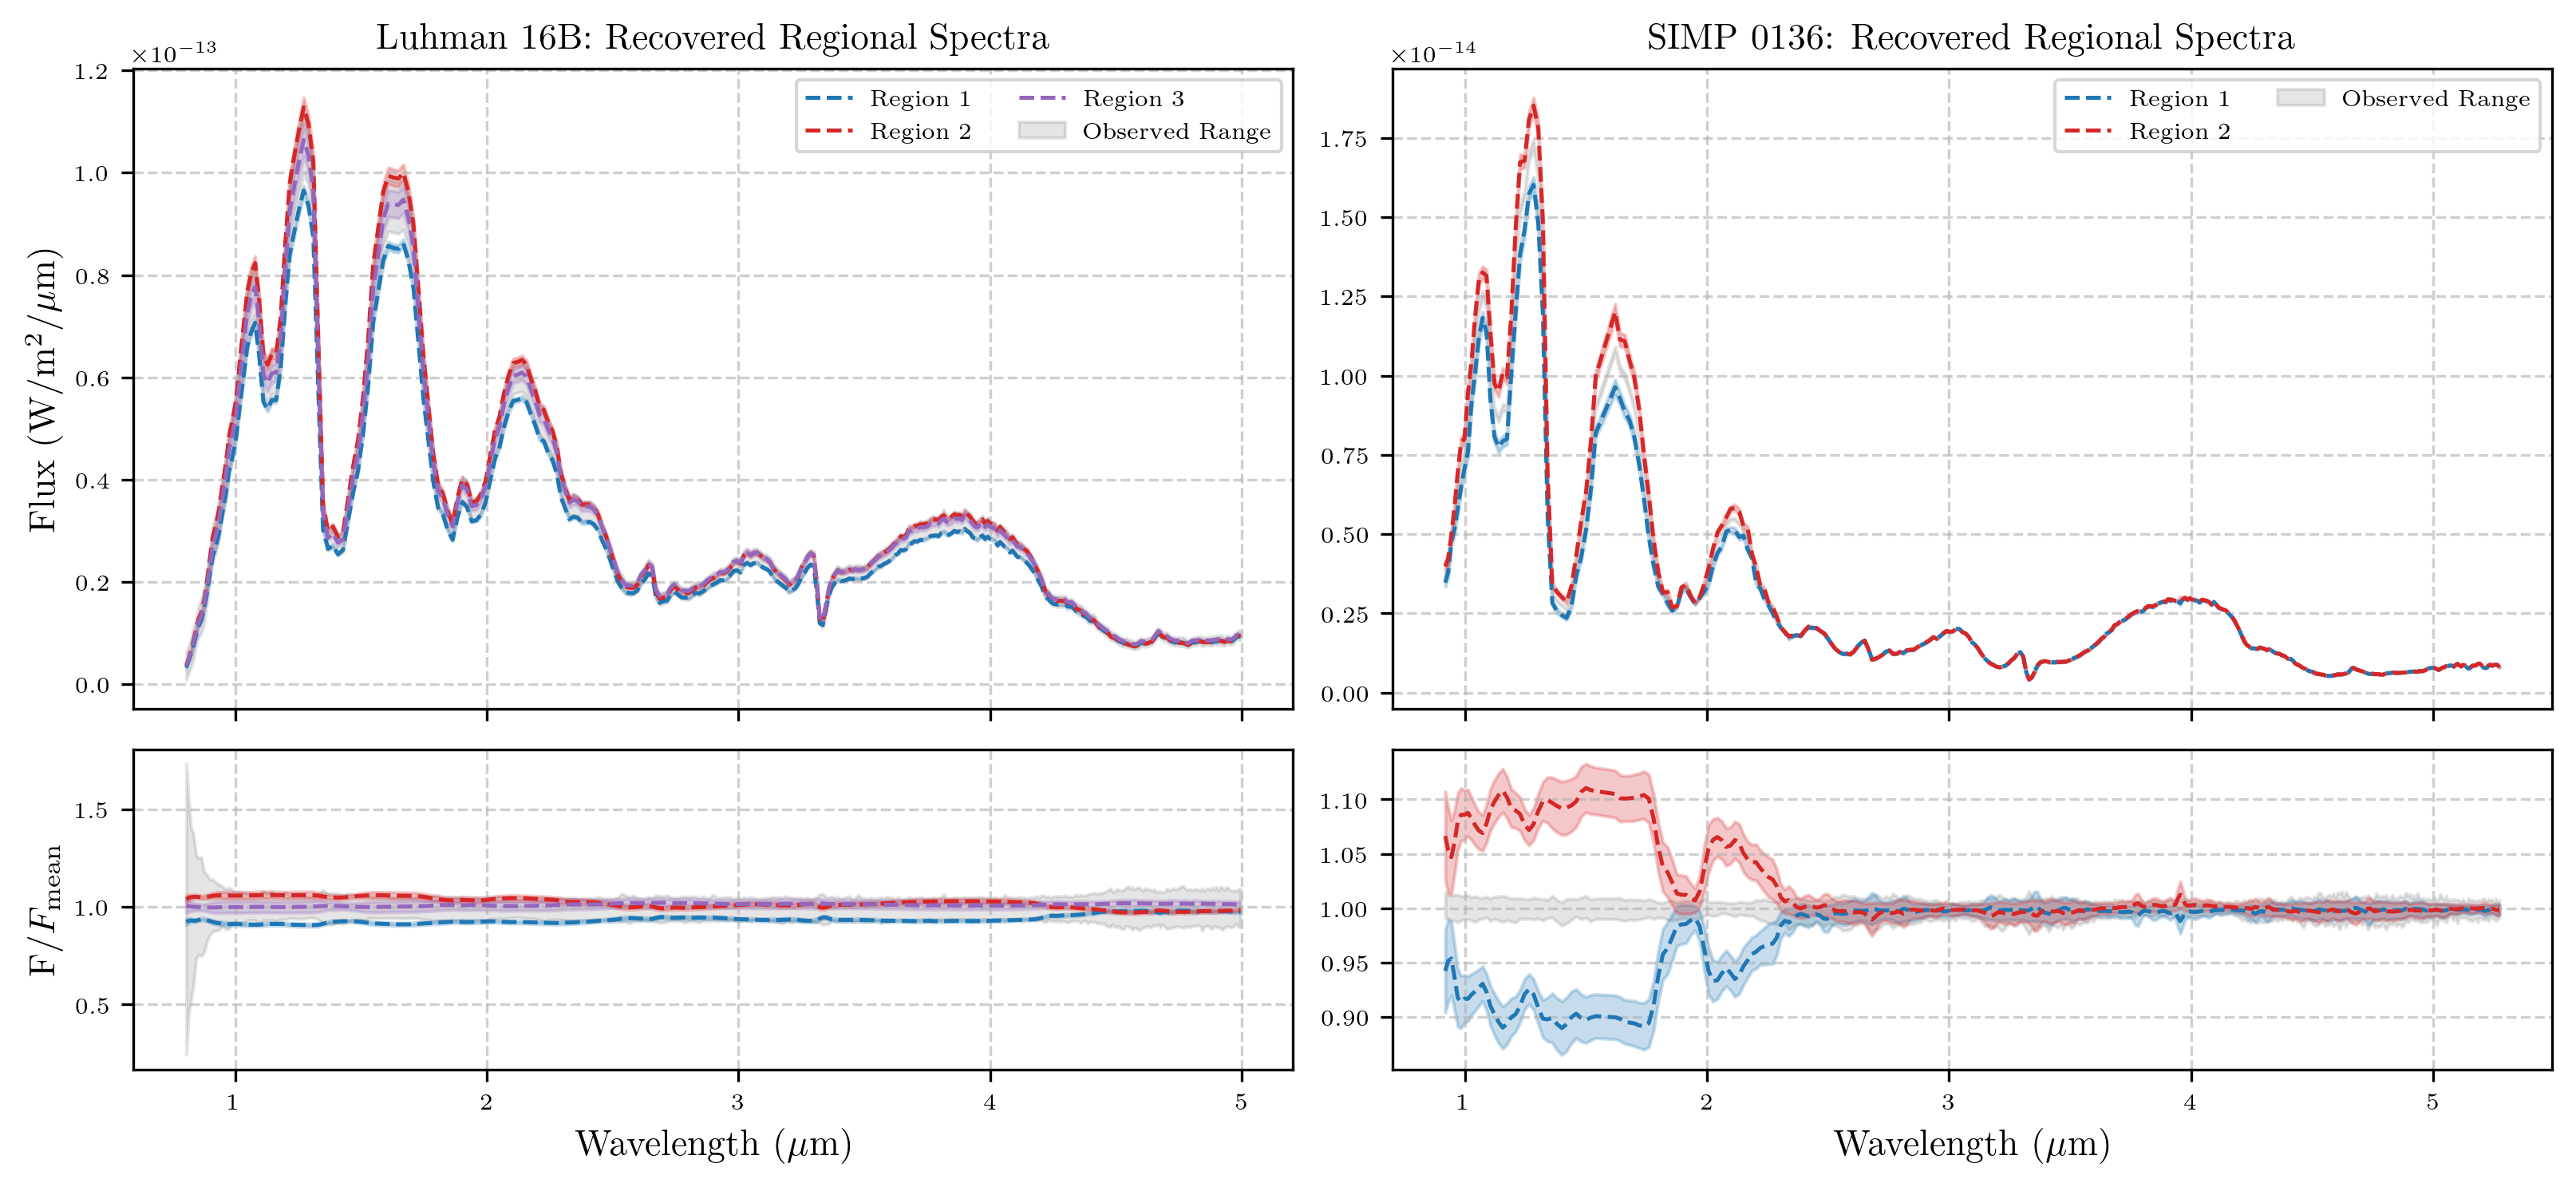

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr
from scipy.ndimage import gaussian_filter1d

fig, axs = plt.subplots(
    2,
    2,
    figsize=(10.8, 5.0),
    sharex='col',
    gridspec_kw={'height_ratios': [2, 1]},
)

plot_specs = [
    ("Luhman 16B", luh_wl, luh_F_regionals, luh_F_regional_errs, luh_cluster_names, luh_flux_raw),
    ("SIMP 0136", simp_wl, simp_F_regionals, simp_F_regional_errs, simp_cluster_names, simp_flux_raw),
]

# Smooth spectra with a Gaussian filter before plotting.
gaussian_sigma = 1

for col, (title, wl_obj, F_reg_obj, F_err_obj, names_obj, flux_raw_obj) in enumerate(plot_specs):
    ax_flux = axs[0, col]
    ax_res = axs[1, col]

    n_obj = len(F_reg_obj)
    color_list = COLOR_LIST[:n_obj]
    background_flux = F_reg_obj[0]

    # Plot the recovered spectra for each non-background region.
    for i in range(1, n_obj):
        mean_flux = F_reg_obj[i]
        error_flux = F_err_obj[i]
        color = color_list[i]
        label = names_obj[i]

        ax_flux.plot(wl_obj, mean_flux, label=label, color=color, linewidth=1.2, linestyle='--')
        ax_flux.fill_between(
            wl_obj,
            mean_flux - error_flux,
            mean_flux + error_flux,
            alpha=0.25,
            color=color,
        )

        ax_res.plot(
            wl_obj,
            gaussian_filter1d(mean_flux / background_flux, sigma=gaussian_sigma, mode='nearest'),
            label=label,
            color=color,
            linewidth=1.2,
            linestyle='--',
        )
        ax_res.fill_between(
            wl_obj,
            (gaussian_filter1d(mean_flux / background_flux, sigma=gaussian_sigma, mode='nearest') - gaussian_filter1d(error_flux / background_flux, sigma=gaussian_sigma, mode='nearest')),
            (gaussian_filter1d(mean_flux / background_flux, sigma=gaussian_sigma, mode='nearest') + gaussian_filter1d(error_flux / background_flux, sigma=gaussian_sigma, mode='nearest')),
            alpha=0.25,
            color=color,
        )

    # Overlay observed time-series variability range.
    time_series = np.sort(flux_raw_obj.T, axis=0)
    ax_flux.fill_between(
        wl_obj,
        time_series[0, :],
        time_series[-1, :],
        color='black',
        alpha=0.10,
        zorder=0,
        label='Observed Range',
    )
    ax_res.fill_between(
        wl_obj,
        time_series[0, :] / background_flux,
        time_series[-1, :] / background_flux,
        color='black',
        alpha=0.10,
        zorder=0,
    )

    ax_flux.set_title(f"{title}: Recovered Regional Spectra", fontsize=11)
    ax_res.set_xlabel(r"Wavelength ($\mu$m)", fontsize=11)
    ax_flux.legend(loc='upper right', ncol=2)

axs[0, 0].set_ylabel(r"Flux (W/m$^2$/$\mu$m)", fontsize=11)
axs[1, 0].set_ylabel(r"F/$F_{\rm{mean}}$", fontsize=11)

plt.tight_layout()
plt.savefig(PAPER_FIGURES_DIR + "Luhman16B_S0136_recovered_spectra_combined.pdf", dpi=300, bbox_inches='tight')